<a href="https://colab.research.google.com/github/AstraLucy/SkinSight/blob/main/skinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Sight Model

In [4]:
# Load keras model

from google.colab import drive
drive.mount('/content/drive')

model = tf.keras.models.load_model("/content/drive/MyDrive/Models/V1/V1.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Validate GPU is active

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Check GPU

import tensorflow as tf

print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))

Built with CUDA: True
GPUs: []


In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/Datasets/Skin_Condition_DS"
val_dir = "/content/drive/MyDrive/Datasets/val"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Setup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os


print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
# Parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [10]:
# Load Dataset, Split off 70% for training

SEED = 123

data_dir = "/content/drive/MyDrive/Datasets/Skin_Condition_DS"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,   # 30% held out
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 27153 files belonging to 10 classes.
Using 19008 files for training.
Found 27153 files belonging to 10 classes.
Using 8145 files for validation.
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [11]:
# Split 20% for Validation and 10% for Testing
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = int(0.67 * temp_batches)  # 20% of total
test_size = temp_batches - val_size  # 10% of total

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

print("Validation batches:", val_size)
print("Test batches:", test_size)

Validation batches: 170
Test batches: 85


In [ ]:
# Performance optimization

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [8]:
# Load Pretrained Model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Build Model

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# Train Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 570s 953ms/step - accuracy: 0.5621 - loss: 1.2245 - val_accuracy: 0.6248 - val_loss: 0.9870
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 826ms/step - accuracy: 0.6430 - loss: 0.9396 - val_accuracy: 0.6463 - val_loss: 0.9071
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 827ms/step - accuracy: 0.6657 - loss: 0.8888 - val_accuracy: 0.6623 - val_loss: 0.8694
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 489s 823ms/step - accuracy: 0.6759 - loss: 0.8419 - val_accuracy: 0.6730 - val_loss: 0.8641
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 490s 826ms/step - accuracy: 0.6929 - loss: 0.8137 - val_accuracy: 0.6695 - val_loss: 0.8772
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 491s 826ms/step - accuracy: 0.6967 - loss: 0.8010 - val_accuracy: 0.6748 - val_loss: 0.8695
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 492s 829ms/step - accuracy: 0.7073 - loss: 0.7701 - val_accuracy: 0.6827 - val_loss: 0.8446
Epoch 8/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 492s 828ms/step - accuracy: 0.7124 -

In [12]:
# Fine-Tuning

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/5
 11/594 ━━━━━━━━━━━━━━━━━━━━ 1:13:23 8s/step - accuracy: 0.4810 - loss: 1.3190

KeyboardInterrupt: 

In [ ]:
# Save Model

model.save("/content/drive/MyDrive/Models/V1/V1.keras")

In [ ]:
# Evaluate on Test Data

model.evaluate(test_ds)

85/85 ━━━━━━━━━━━━━━━━━━━━ 62s 636ms/step - accuracy: 0.6924 - loss: 0.8271


[0.827096700668335, 0.6924214363098145]

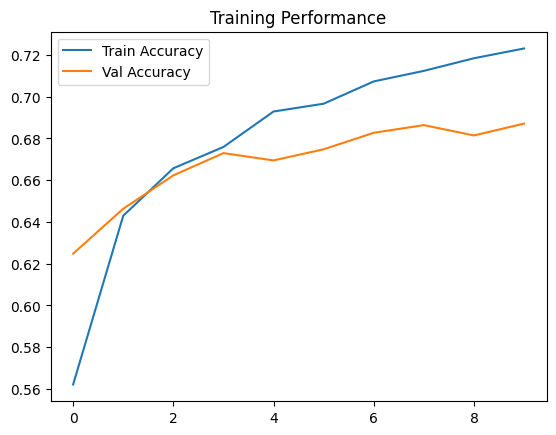

In [ ]:
# Plot Results

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.legend()
plt.title("Training Performance")
plt.show()

In [13]:
# Convert to tensorflow lite model

# Create converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Convert
tflite_model = converter.convert()

# Save to file
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpc5lmf1tj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139965013961488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013962640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013962064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013965520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963

In [15]:
# Apply Float16 quantisation

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

Saved artifact at '/tmp/tmpz9wnmqua'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139965013961488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013962640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013962064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013964560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013965520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139965013963

In [18]:
# Save tensorflow lite model

with open("/content/drive/MyDrive/Models/V1/V1.tflite", "wb") as f:
    f.write(tflite_model)